Cross-validate and compare models

In [41]:
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# load data
X_train = pd.read_parquet("/content/drive/MyDrive/data/X_train.parquet")
X_test = pd.read_parquet("/content/drive/MyDrive/data/X_test.parquet")
y_train = pd.read_parquet("/content/drive/MyDrive/data/y_train.parquet").iloc[:, 0] # convert labels from df to series (all rows, 1st col)
y_test = pd.read_parquet("/content/drive/MyDrive/data/y_test.parquet").iloc[:, 0]

In [44]:
# initialize 3 models for comparison
lr_pipe_C1 = make_pipeline(StandardScaler(), LogisticRegression(C=1.0,  max_iter=1000, random_state=42))
lr_pipe_C001 = make_pipeline(StandardScaler(), LogisticRegression(C=0.01, max_iter=1000, random_state=42))
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)

In [45]:
# fit models to training data
lr_pipe_C1.fit(X_train, y_train)
lr_pipe_C001.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [46]:
# 10-fold cross-validation for all 3 models
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits = 10, shuffle=True, random_state=42)

models = {
    "LR (C=1.0)": lr_pipe_C1,
    "LR (C=0.01)": lr_pipe_C001,
    "RF": rf
}

results = {}

for name, model in models.items():
  scores = cross_val_score(model, X_train, y_train, cv = cv, scoring='average_precision', n_jobs = -1)
  results[name] = scores
  print(f"{name}: PR-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

LR (C=1.0): PR-AUC = 0.2891 +/- 0.0285
LR (C=0.01): PR-AUC = 0.2892 +/- 0.0287
RF: PR-AUC = 0.2632 +/- 0.0199


/tmp/ipykernel_19016/994976566.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels = results.keys())


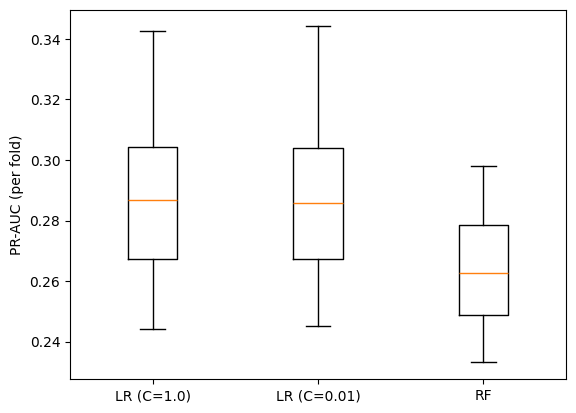

In [47]:
# boxplot of 10 per-fold scores per model
import matplotlib.pyplot as plt

plt.boxplot(results.values(), labels = results.keys())
plt.ylabel("PR-AUC (per fold)")

plt.savefig('/content/drive/MyDrive/data/cv_boxplot.png')
plt.show()

LR models overlap heavily, appear to be statistically indistinguishable...

In [48]:
# paired t-test on per-fold differences (same fold = same data, use ttest_related)
from scipy.stats import ttest_rel

stat, pval = ttest_rel(results['LR (C=1.0)'], results["RF"])
print(f"LR vs RF: t={stat:.2f}, p={pval:.4f}")

LR vs RF: t=5.98, p=0.0002


Model differences between LR and RF are significant at both a=0.05 and a=0.01

In [49]:
# build function to compute net profit when targeting top-K predicted churners, using predict_proba
import numpy as np
def net_profit(model, X_test, y_test, K, cost=5, save_value=30):
    probs = model.predict_proba(X_test)[:, 1]
    top_k_idx = np.argsort(probs)[-K:]
    n_real_churners = y_test.iloc[top_k_idx].sum()
    n_non_churners = K - n_real_churners
    profit = n_real_churners * save_value - K * cost
    precision = n_real_churners / K
    return profit, precision

In [50]:
# create a comparison table
results = {'LR (C=1.0)' : lr_pipe_C1,
           'LR (C=0.01)': lr_pipe_C001,
           'RF' : rf}

K_values = [200, 400, 800, 1500]

results = []
for name, model in models.items():
    for K in K_values:
        profit, precision = net_profit(model, X_test, y_test, K)
        results.append({
            'model': name,
            'K': K,
            'profit': profit,
            'precision': precision
        })

In [51]:
comparison_df = pd.DataFrame(results)
comparison_df['combined'] = comparison_df.apply(
    lambda row: f"{row['profit']:.0f} / {row['precision']:.2f}", axis=1
)

combined_table = comparison_df.pivot(index='model', columns='K', values='combined')
combined_table

K,200,400,800,1500
model,,,,
LR (C=0.01),1670 / 0.45,2530 / 0.38,3500 / 0.31,3540 / 0.25
LR (C=1.0),1670 / 0.45,2530 / 0.38,3470 / 0.31,3570 / 0.25
RF,1520 / 0.42,2080 / 0.34,2870 / 0.29,3090 / 0.24


Recommendations: Ship model LR C=1.0 because maximizes profit at the retention team's actual capacity (K=400) with a statistically significant margin. It is simpler and easy to monitor--PR-AUC supports LR model selection. Caveats include data drift in production. More features or a better target definition can improve model predictions.